# Working with imaging phenotypes (Y data)

In real neuroimaging studies, you rarely have a single group-average brain map ready to go. More often you have individual subject images that you need to transform into a group-level phenotype before you can run a colocalization.

This notebook covers:
- Computing group-level effect sizes with `transform_y()` (Hedges' g, Cohen's d, z-scores, percentiles)
- Removing confounding effects with `clean_y()` (covariate regression, ComBat harmonization)

We use the `"anorexianervosa"` example dataset: 50 patients and 50 healthy controls with parcellated grey matter values.

> **Note:** This dataset is **simulated** and not intended for scientific use. The numbers are realistic but fabricated — do not draw any clinical or scientific conclusions from it.

In [2]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

## Load the example dataset

The anorexia nervosa example dataset contains parcellated grey matter maps for 100 subjects. The group labels are encoded in the subject IDs.

In [3]:
from nispace.datasets import fetch_example, fetch_reference

# load individual subject data
an_data = fetch_example("anorexianervosa", parcellation="Yan200")

# extract group labels from subject IDs
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

print(f"Data: {an_data.shape[0]} subjects x {an_data.shape[1]} parcels")
print(f"Groups: {pd.Series(groups).value_counts().to_dict()}")
an_data.head(3)

INFO | 13/07/26 14:58:16 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Yan200.


Data: 100 subjects x 200 parcels
Groups: {'AN': 50, 'HC': 50}


,hemi-L_div-DefaultC_lab-IPL,hemi-L_div-DefaultC_lab-PHC,hemi-L_div-DefaultB_lab-IPL+1,hemi-L_div-DefaultB_lab-IPL+2,hemi-L_div-DefaultB_lab-PFCd+1,hemi-L_div-DefaultB_lab-PFCd+2,hemi-L_div-DefaultB_lab-PFCl,hemi-L_div-DefaultB_lab-PFCm,hemi-L_div-DefaultB_lab-PFCv+1,hemi-L_div-DefaultB_lab-PFCv+2,...,hemi-R_div-VisualB_lab-ExStrSup,hemi-R_div-VisualB_lab-Striate+1,hemi-R_div-VisualB_lab-Striate+2,hemi-R_div-VisualA_lab-ExStr+1,hemi-R_div-VisualA_lab-ExStr+2,hemi-R_div-VisualA_lab-ExStr+3,hemi-R_div-VisualA_lab-ExStr+4,hemi-R_div-VisualA_lab-SPL,hemi-R_div-VisualA_lab-TempOcc+1,hemi-R_div-VisualA_lab-TempOcc+2
sub-001AN,0.395605,0.669223,0.548818,0.408243,0.430513,0.502311,0.458284,0.603141,0.502833,0.711776,...,0.525555,0.590987,0.668358,0.426307,0.515936,0.577865,0.671952,0.389983,0.571689,0.655690
sub-002AN,0.571406,0.561196,0.509263,0.567479,0.542529,0.568723,0.300007,0.482455,0.443508,0.408429,...,0.714584,0.471272,0.409470,0.490916,0.551336,0.593906,0.732056,0.223000,0.635858,0.569313
sub-003AN,0.514115,0.717621,0.557405,0.565744,0.415440,0.439508,0.500341,0.565273,0.517572,0.645602,...,0.653885,0.606883,0.552585,0.593439,0.602404,0.521838,0.783902,0.365947,0.509347,0.579830


## Setting up NiSpace with individual subject data

When `y` is a DataFrame with one row per subject, NiSpace treats it as individual-level data. We pass the group vector separately when we call `transform_y()`.

We also load the PET reference data.

In [4]:
from nispace.api import NiSpace

pet_maps = fetch_reference("pet", parcellation="Yan200",
                           collection="UniqueTracers", print_references=False)

nsp = NiSpace(
    x=pet_maps,
    y=an_data,         # individual subject maps — one row per subject
    parcellation="Yan200",
    n_proc=4,
    seed=42
)
nsp.fit()
print(f"Fitted. Y shape: {nsp.get_y().shape}")

INFO | 13/07/26 14:58:16 | nispace.datasets: Loading pet maps.


INFO | 13/07/26 14:58:16 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 13/07/26 14:58:16 | nispace.datasets: Filtering maps by collection.


INFO | 13/07/26 14:58:16 | nispace.datasets: Loading data parcellated with 'Yan200'


INFO | 13/07/26 14:58:16 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


...

INFO | 13/07/26 14:58:17 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 13/07/26 14:58:17 | nispace.api: Got 'y' data for 100 x 200 parcels.


INFO | 13/07/26 14:58:17 | nispace.api: Z-standardizing 'X' data.


INFO | 13/07/26 14:58:17 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


Fitted. Y shape: (100, 200)


## Computing group-level effect sizes with `transform_y()`

To run a spatial colocalization, we need a single group-level map. `transform_y()` computes this for us, using a formula that specifies the comparison.

The group vector tells NiSpace which subjects belong to which group. The convention is that group "a" (here: `AN`) is compared against group "b" (here: `HC`).

### Hedges' g

Hedges' g is a bias-corrected version of Cohen's d — the most common effect size metric for group comparisons. A negative g at a given parcel means the AN group has lower grey matter there compared to controls.

In [5]:
# compute Hedges' g: AN vs. HC
# the formula "hedges(a,b)" computes Hedges' g for group a (AN) vs. group b (HC)
nsp.transform_y(
    transform="hedges(a,b)",
    groups=groups  # vector of group labels, same length as number of subjects
)

hedges_g = nsp.get_y()
print(f"After transform_y: {hedges_g.shape}  (one row = one group comparison)")
print(f"Value range: [{hedges_g.values.min():.2f}, {hedges_g.values.max():.2f}]")
hedges_g

INFO | 13/07/26 14:58:17 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 13/07/26 14:58:17 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 13/07/26 14:58:17 | nispace.api: Applying Y transform 'hedges(a,b)'.


INFO | 13/07/26 14:58:17 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


After transform_y: (1, 200)  (one row = one group comparison)
Value range: [-0.28, 0.81]


,hemi-L_div-DefaultC_lab-IPL,hemi-L_div-DefaultC_lab-PHC,hemi-L_div-DefaultB_lab-IPL+1,hemi-L_div-DefaultB_lab-IPL+2,hemi-L_div-DefaultB_lab-PFCd+1,hemi-L_div-DefaultB_lab-PFCd+2,hemi-L_div-DefaultB_lab-PFCl,hemi-L_div-DefaultB_lab-PFCm,hemi-L_div-DefaultB_lab-PFCv+1,hemi-L_div-DefaultB_lab-PFCv+2,...,hemi-R_div-VisualB_lab-ExStrSup,hemi-R_div-VisualB_lab-Striate+1,hemi-R_div-VisualB_lab-Striate+2,hemi-R_div-VisualA_lab-ExStr+1,hemi-R_div-VisualA_lab-ExStr+2,hemi-R_div-VisualA_lab-ExStr+3,hemi-R_div-VisualA_lab-ExStr+4,hemi-R_div-VisualA_lab-SPL,hemi-R_div-VisualA_lab-TempOcc+1,hemi-R_div-VisualA_lab-TempOcc+2
hedges,0.425695,-0.135293,0.082829,0.119046,0.802301,0.639899,0.123048,0.404956,0.200989,-0.03711,...,0.370616,0.004897,0.180153,0.06616,0.023523,-0.136696,-0.119192,0.470423,0.500066,0.309513


INFO | 13/07/26 14:58:17 | nispace.api: *** NiSpace.plot_brain() ***


INFO | 13/07/26 14:58:17 | nispace.api: Plotting Y data (Y_transform='hedges(a,b)').


INFO | 13/07/26 14:58:17 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


WARNING | 13/07/26 14:58:17 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!


INFO | 13/07/26 14:58:17 | nispace.plotting: brainplot: threshold='auto' → 0.0005194987752474844


INFO | 13/07/26 14:58:17 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsym'.


INFO | 13/07/26 14:58:17 | nispace.core.parcellation: Parcellation 'Yan200': active space set to 'MNI152NLin2009cAsym'.


INFO | 13/07/26 14:58:17 | nispace.plotting: brainplot: kind='glass', img_mode='None', surf_space='None', mni_space='MNI152NLin2009cAsym', surf_mesh='inflated'


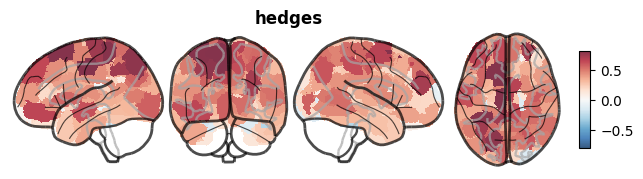

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

In [6]:
# visualize on the brain
nsp.plot_brain(data="Y", symmetric_cmap=True)

Widespread negative values are expected: anorexia nervosa is associated with global grey matter reductions, most pronounced in frontal and temporal regions.

### Cohen's d

Cohen's d is the non-bias-corrected version. With n=50 per group the difference from Hedges' g is minimal, but it's good to know both are available.

In [7]:
nsp.transform_y(transform="cohen(a,b)", groups=groups)
cohens_d = nsp.get_y()
print(f"Cohen's d range: [{cohens_d.values.min():.2f}, {cohens_d.values.max():.2f}]")

INFO | 13/07/26 14:58:20 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 13/07/26 14:58:20 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 13/07/26 14:58:20 | nispace.api: Applying Y transform 'cohen(a,b)'.


INFO | 13/07/26 14:58:20 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| cohen(a,b)  | 


Cohen's d range: [-0.28, 0.81]


### Z-scores (individual deviation maps)

Instead of a single group map, we can compute a deviation map for each patient: how many standard deviations does this individual deviate from the control mean at each parcel? This is useful for individual-level analyses — see [Notebook 11](intro11_advanced.ipynb).

In [8]:
# z-score: each AN subject mapped relative to HC mean and SD
nsp.transform_y(transform="zscore(a,b)", groups=groups)

zscores = nsp.get_y()
print(f"Z-score maps: {zscores.shape}  (one row per AN subject)")
zscores.head(3)

INFO | 13/07/26 14:58:20 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 13/07/26 14:58:20 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 13/07/26 14:58:20 | nispace.api: Applying Y transform 'zscore(a,b)'.


INFO | 13/07/26 14:58:20 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| zscore(a,b) | 


Z-score maps: (50, 200)  (one row per AN subject)


,hemi-L_div-DefaultC_lab-IPL,hemi-L_div-DefaultC_lab-PHC,hemi-L_div-DefaultB_lab-IPL+1,hemi-L_div-DefaultB_lab-IPL+2,hemi-L_div-DefaultB_lab-PFCd+1,hemi-L_div-DefaultB_lab-PFCd+2,hemi-L_div-DefaultB_lab-PFCl,hemi-L_div-DefaultB_lab-PFCm,hemi-L_div-DefaultB_lab-PFCv+1,hemi-L_div-DefaultB_lab-PFCv+2,...,hemi-R_div-VisualB_lab-ExStrSup,hemi-R_div-VisualB_lab-Striate+1,hemi-R_div-VisualB_lab-Striate+2,hemi-R_div-VisualA_lab-ExStr+1,hemi-R_div-VisualA_lab-ExStr+2,hemi-R_div-VisualA_lab-ExStr+3,hemi-R_div-VisualA_lab-ExStr+4,hemi-R_div-VisualA_lab-SPL,hemi-R_div-VisualA_lab-TempOcc+1,hemi-R_div-VisualA_lab-TempOcc+2
sub-001AN,-0.695940,0.766821,1.102321,-1.523983,-0.438927,0.945216,-0.095740,0.713528,-0.570642,1.090056,...,0.093614,-0.248421,1.760566,-0.814122,-0.844469,0.878123,-0.343425,0.616641,0.239616,0.419657
sub-002AN,1.227013,-0.262803,0.680166,0.193541,0.689162,1.642317,-1.527394,-0.503622,-1.270175,-2.350476,...,2.235084,-1.567924,-0.798811,-0.139120,-0.470211,1.061118,0.331186,-1.251176,0.948248,-0.490665
sub-003AN,0.600354,1.228111,1.193975,0.174824,-0.590723,0.285994,0.284675,0.331622,-0.396841,0.339510,...,1.547442,-0.073218,0.616034,0.931979,0.069702,0.238976,0.913098,0.347789,-0.448839,-0.379828


### Centile scores (group-relative percentile rank)

Centile scores place each patient on the normative percentile scale at each parcel: a value of 10 at a given parcel means the patient's grey matter there is lower than 90% of healthy controls. This is a normative modeling approach useful for characterizing individual patients against a reference population.

Like z-scores, this produces one map per patient — useful for individual-level analyses.

In [9]:
# centile: each AN subject ranked within HC distribution
nsp.transform_y(transform="centile(a,b)", groups=groups)

centiles = nsp.get_y()
print(f"Centile maps: {centiles.shape}  (one row per AN subject)")
print(f"Value range: [{centiles.values.min():.1f}, {centiles.values.max():.1f}] (percentile, 0–100)")
centiles.head(3)

INFO | 13/07/26 14:58:20 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 13/07/26 14:58:20 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 13/07/26 14:58:20 | nispace.api: Applying Y transform 'centile(a,b)'.


INFO | 13/07/26 14:58:20 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM  | 
| centile(a,b) | 


Centile maps: (50, 200)  (one row per AN subject)
Value range: [0.0, 100.0] (percentile, 0–100)


,hemi-L_div-DefaultC_lab-IPL,hemi-L_div-DefaultC_lab-PHC,hemi-L_div-DefaultB_lab-IPL+1,hemi-L_div-DefaultB_lab-IPL+2,hemi-L_div-DefaultB_lab-PFCd+1,hemi-L_div-DefaultB_lab-PFCd+2,hemi-L_div-DefaultB_lab-PFCl,hemi-L_div-DefaultB_lab-PFCm,hemi-L_div-DefaultB_lab-PFCv+1,hemi-L_div-DefaultB_lab-PFCv+2,...,hemi-R_div-VisualB_lab-ExStrSup,hemi-R_div-VisualB_lab-Striate+1,hemi-R_div-VisualB_lab-Striate+2,hemi-R_div-VisualA_lab-ExStr+1,hemi-R_div-VisualA_lab-ExStr+2,hemi-R_div-VisualA_lab-ExStr+3,hemi-R_div-VisualA_lab-ExStr+4,hemi-R_div-VisualA_lab-SPL,hemi-R_div-VisualA_lab-TempOcc+1,hemi-R_div-VisualA_lab-TempOcc+2
sub-001AN,22.0,80.0,90.0,6.0,28.0,84.0,44.0,78.0,26.0,82.0,...,50.0,40.0,92.0,24.0,18.0,78.0,42.0,74.0,64.0,68.0
sub-002AN,86.0,36.0,80.0,60.0,72.0,98.0,4.0,30.0,8.0,0.0,...,100.0,8.0,20.0,46.0,36.0,86.0,68.0,14.0,82.0,36.0
sub-003AN,74.0,90.0,90.0,60.0,20.0,66.0,62.0,68.0,36.0,64.0,...,94.0,52.0,76.0,78.0,58.0,62.0,80.0,62.0,34.0,40.0


For colocalization analyses, we typically average across subjects to get one group-level map. The Hedges' g approach does this in one step. But for individual-level colocalization you'd keep all rows and analyze them separately.

## Removing confounds with `clean_y()`

Grey matter maps are affected by confounds that have nothing to do with the disorder: age, sex, total intracranial volume, and scanner site are the usual suspects. `clean_y()` lets you regress these out before running colocalization.

NiSpace distinguishes between two types of regression:

- **"within"**: regression *across parcels* within each map (e.g., regressing out a whole-brain grey matter map to control for global effects)
- **"between"**: regression *across subjects* (e.g., removing age or sex effects)

Let's generate a synthetic age vector for demonstration and show how to regress it out.

In [10]:
# reset to individual subject data for this demo
nsp_clean = NiSpace(
    x=pet_maps,
    y=an_data,
    parcellation="Yan200",
    seed=42
)
nsp_clean.fit()

# generate a synthetic age vector: AN mean=25, HC mean=30, SD=5 for both
# (realistic for this kind of study)
rng = np.random.default_rng(42)
age_AN = rng.normal(25, 5, 50)
age_HC = rng.normal(30, 5, 50)
age = np.concatenate([age_AN, age_HC])

# sex: roughly balanced (0=male, 1=female), NiSpace treats string covariates automatically as categorical
sex = rng.permutation(["f"]*80 + ["m"]*20)

print(f"Age: mean={age.mean():.1f}, SD={age.std():.1f}")
print(f"Sex: {(sex=='f').sum()} female, {(sex=='m').sum()} male")

INFO | 13/07/26 14:58:20 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 13/07/26 14:58:20 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010


INFO | 13/07/26 14:58:20 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage


INFO | 13/07/26 14:58:21 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.


INFO | 13/07/26 14:58:21 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

INFO | 13/07/26 14:58:21 | nispace.api: Checking input data for 'y' (should be, e.g., subject data):


INFO | 13/07/26 14:58:21 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 13/07/26 14:58:21 | nispace.api: Got 'y' data for 100 x 200 parcels.


INFO | 13/07/26 14:58:21 | nispace.api: Z-standardizing 'X' data.


Age: mean=27.2, SD=4.2
Sex: 80 female, 20 male


In [11]:
# regress age and sex out from the individual subject maps
# how="between" means: regression across subjects
# covariates_between is a DataFrame with one row per subject
covariates = pd.DataFrame({"age": age, "sex": sex}, index=an_data.index)

nsp_clean.clean_y(
    how="between",
    covariates_between=covariates
)

print("Covariate regression done.")
print(f"Y shape after cleaning: {nsp_clean.get_y().shape}")

INFO | 13/07/26 14:58:21 | nispace.api: *** NiSpace.clean_y() - Y covariate regression. ***


INFO | 13/07/26 14:58:21 | nispace.api: Performing covariate regression between maps/subjects (e.g., age, sex, site).


INFO | 13/07/26 14:58:21 | nispace.core.clean_y: Detected categorical covariates: ['sex']; continuous: ['age'].


INFO | 13/07/26 14:58:21 | nispace.core.clean_y: Regressing 2 between covariate(s) from Y.


Regressing 2 between covariate(s) from Y (1 proc): 100%|███████████████████████████████| 200/200 [00:00<00:00, 14717.89it/s]

Covariate regression done.
INFO | 13/07/26 14:58:21 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| False       | 


Y shape after cleaning: (100, 200)


After cleaning, we can compute effect sizes on the covariate-corrected maps:

In [12]:
nsp_clean.transform_y(transform="hedges(a,b)", groups=groups)
hedges_g_clean = nsp_clean.get_y()

print(f"Hedges' g after covariate regression: range [{hedges_g_clean.values.min():.2f}, {hedges_g_clean.values.max():.2f}]")

INFO | 13/07/26 14:58:21 | nispace.api: *** NiSpace.transform_y() - Y transformation and comparison. ***


INFO | 13/07/26 14:58:21 | nispace.api: Groups/sessions vector provided, ensuring dummy-coding.


INFO | 13/07/26 14:58:21 | nispace.api: Applying Y transform 'hedges(a,b)'.


INFO | 13/07/26 14:58:21 | nispace.api: Returning Y dataframe: 
| Y_TRANSFORM | 
| hedges(a,b) | 


Hedges' g after covariate regression: range [-0.21, 0.83]


### ComBat harmonization

If your data comes from multiple scanners or study sites, `clean_y()` also supports ComBat harmonization (a Bayesian framework for removing scanner effects while preserving biological variability). Pass `combat=True` and include a `"site"` column in your covariates DataFrame:

```python
covariates_with_site = pd.DataFrame({
    "age": age,
    "sex": sex,
    "site": site_labels  # scanner/site identifier per subject
}, index=an_data.index)

nsp_clean.clean_y(
    how="between",
    covariates_between=covariates_with_site,
    combat=True
)
```

ComBat removes site effects while keeping the biological covariates (age, sex) protected.

## The full preprocessing pipeline

Putting it all together, a typical preprocessing pipeline before colocalization looks like this:

```python
nsp = NiSpace(x=pet_maps, y=an_data, parcellation="Yan200")
nsp.fit()                                      # parcellate
nsp.clean_y(                                   # remove confounds
    how="between",
    covariates_between=covariates
)
nsp.transform_y(                               # compute effect sizes
    transform="hedges(a,b)",
    groups=groups
)
nsp.colocalize("spearman")                     # correlate with reference
nsp.permute("groups", n_perm=10000)            # permutation test (group labels)
nsp.plot()
```

Note that when group labels are permuted (`permute("groups")`), we permute the subject labels before computing the effect size — this gives a more principled null model than permuting the maps. This is covered in detail in [Notebook 5](intro05_null_models.ipynb).

## Summary

| Method | What it does |
|--------|--------------|
| `transform_y("hedges(a,b)", groups=...)` | Hedges' g per parcel (bias-corrected effect size, group a vs. b) |
| `transform_y("cohen(a,b)", groups=...)` | Cohen's d per parcel |
| `transform_y("zscore(a,b)", groups=...)` | Z-score per subject (group a relative to b distribution) |
| `transform_y("centile(a,b)", groups=...)` | Centile score per subject (percentile rank within group b) |
| `clean_y(how="between", covariates_between=df)` | Regress out between-subject confounds |
| `clean_y(how="within", covariates_within=df)` | Regress out within-map confounds (e.g., grey matter) |
| `clean_y(..., combat=True)` | ComBat site harmonization |

Next: [Notebook 5](intro05_null_models.ipynb) covers the null model methods in detail.